# EquityAgent: Data and NLP starter

GitHub repository: <repo-url>

This notebook covers the **Data lead** and **NLP lead** starting tasks:

1. Setup
2. Data check: each tool returns data (prices, technicals, macro, news,
   10-K sections)
3. Kaggle news EDA: label balance, duplicates, headline length, held-out
   sample
4. Classifier evaluation: keyword baseline vs LLM on the held-out sample
5. News prompt chain: output of each step on a live ticker

In [20]:
from google.colab import userdata

ORG = "nicole-rowley-msaai"
REPO_NAME = "MS_AAI_520_NLP_GenAI_Final"
token = userdata.get("GITHUB_TOKEN")

!git remote set-url origin https://{token}@github.com/{ORG}/{REPO_NAME}.git
!git fetch origin
!git checkout data_nlp
!git branch --set-upstream-to=origin/data_nlp data_nlp
!git push origin data_nlp

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 6.07 KiB | 30.00 KiB/s, done.
From https://github.com/nicole-rowley-msaai/MS_AAI_520_NLP_GenAI_Final
 * [new branch]      data_nlp   -> origin/data_nlp
 * [new branch]      main       -> origin/main
error: Your local changes to the following files would be overwritten by checkout:
	notebooks/01_data_and_nlp_520_equity_agent.ipynb
Please commit your changes or stash them before you switch branches.
Aborting
fatal: branch 'data_nlp' does not exist
error: src refspec data_nlp does not match any
error: failed to push some refs to 'https://github.com/nicole-rowley-msaai/MS_AAI_520_NLP_GenAI_Final.git'


## 1. Setup

In [2]:
# Colab setup
import os
import sys

from google.colab import drive, userdata

REPO_URL = "https://github.com/nicole-rowley-msaai/MS_AAI_520_NLP_GenAI_Final.git"
REPO = "/content/drive/MyDrive/equity-agent"

drive.mount("/content/drive")

# Clone on first run; pull the latest commit on later runs.
if os.path.isdir(os.path.join(REPO, ".git")):
    %cd {REPO}
    !git pull -q
else:
    %cd /content/drive/MyDrive
    !git clone -q {REPO_URL}
    %cd {REPO}
sys.path.insert(0, REPO)

# The google-adk warning is a Colab preinstall conflict we do not use.
!pip install -q -r requirements.txt 2>&1 | grep -v "google-adk\|dependency resolver"

# Load keys from Colab Secrets before importing src.config
SECRET_KEYS = [
    "OPENAI_API_KEY",
    "ANTHROPIC_API_KEY",
    "FRED_API_KEY",
    "NEWSAPI_KEY",
    "EDGAR_USER_AGENT",
]
loaded = []
for key in SECRET_KEYS:
    try:
        os.environ[key] = userdata.get(key)
        loaded.append(key)
    except Exception:
        print(f"Missing secret: {key}")
print("Loaded:", loaded)

Mounted at /content/drive
/content/drive/MyDrive/equity-agent
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.7 MB/s eta

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import TICKERS
from src.tools import safe_call

## 2. Data check: does every tool return data?

Each call goes through `safe_call`, so a failed API shows as `ok=False`
instead of stopping the notebook.

In [4]:
from src.tools.filings import extract_sections, get_latest_10k
from src.tools.macro import get_macro_snapshot
from src.tools.market import compute_technicals, get_price_history
from src.tools.news import get_news


def status(result):
    """Every ToolResult field except the data itself."""
    return {k: v for k, v in vars(result).items() if k != "data"}


checks = []
spy = safe_call("prices", get_price_history, "SPY")
for ticker in TICKERS:
    prices = safe_call("prices", get_price_history, ticker)
    checks.append({"ticker": ticker, **status(prices)})
    if prices.ok and spy.ok:
        print(ticker, compute_technicals(prices.data, spy.data))

macro = safe_call("fred", get_macro_snapshot)
checks.append({"ticker": "-", **status(macro)})
pd.DataFrame(checks)

NVDA {'last_close': 230.48, 'return_1m': 0.0304, 'return_1y': 0.2456, 'vol_annualized': 0.378, 'sma_50': 221.39, 'sma_200': 201.93, 'beta_vs_spy': 2.129}
JPM {'last_close': 331.42, 'return_1m': -0.0657, 'return_1y': 0.0771, 'vol_annualized': 0.2241, 'sma_50': 350.5, 'sma_200': 322.09, 'beta_vs_spy': 0.874}
XOM {'last_close': 168.5, 'return_1m': 0.026, 'return_1y': 0.4747, 'vol_annualized': 0.2592, 'sma_50': 161.33, 'sma_200': 150.07, 'beta_vs_spy': 0.388}


,ticker,tool,ok,error,meta
0,NVDA,prices,True,None,{'rows': 1254}
1,JPM,prices,True,None,{'rows': 1254}
2,XOM,prices,True,None,{'rows': 1254}
3,-,fred,True,None,{'rows': 5}


In [5]:
macro.data if macro.ok else macro.error

,series,label,date,latest,one_year_ago
0,CPIAUCSL,"CPI, all urban consumers",2026-08-01,334.131,323.291
1,FEDFUNDS,Effective federal funds rate,2026-09-01,3.750,4.220
2,DGS10,10-year Treasury yield,2026-10-07,5.280,4.140
3,UNRATE,Unemployment rate,2026-09-01,4.200,4.400
4,GDPC1,Real GDP,2026-04-01,24408.011,23884.563


In [6]:
news = safe_call("news", get_news, "NVDA", "Nvidia")
print(news.ok, news.meta, news.error)
pd.DataFrame(news.data[:5]) if news.ok else None

True {'rows': 100} None


,title,description,source,published,url
0,Prediction: Micron Will Have a Larger Market C...,Nvidia (NASDAQ: NVDA) is the world's most valu...,Biztoc.com,2026-10-07T20:31:19Z,https://biztoc.com/x/86780dbb8632ffa2
1,Microsoft releases new Nvidia-chip AI PCs with...,"Back in June, Nvidia announced that it had sec...",Biztoc.com,2026-10-07T20:30:31Z,https://biztoc.com/x/66d3da60d2d757ed
2,"Windows, Surface and Nvidia Event Highlights: ...",Watch Microsoft CEO Satya Nadella and the Wind...,PCMag.com,2026-10-07T20:28:46Z,https://uk.pcmag.com/video/167788/windows-surf...
3,"Windows, Surface and Nvidia Event Highlights: ...",Watch Microsoft CEO Satya Nadella and the Wind...,PCMag.com,2026-10-07T20:28:46Z,https://me.pcmag.com/en/video/38273/windows-su...
4,Microsoft releases new Nvidia-chip AI PCs with...,Microsoft revealed the specs and price for its...,TechCrunch,2026-10-07T20:22:37Z,https://techcrunch.com/2026/10/07/microsoft-re...


**10-K sections.** Three filer quirks surfaced during iteration, and
`src/tools/filings.py` handles each:

- **JPMorgan** embeds its whole annual report in the 10-K file, so "Item 7"
  is only a cross-reference. The extractor falls back to the plain heading
  "Management's discussion and analysis" when the Item 7 span is too short.
- **Exxon** reorganized into ExxonMobil Holdings Corp in mid-2026. The
  ticker now maps to a new SEC registrant with no 10-K, so the loader
  retries the prior entity's CIK from `config.PREDECESSOR_CIKS`.
- **Heavy filers** can push a 10-K off the first page of the SEC
  submissions feed, so the loader follows the paginated files.

The `cik` column below shows which registrant each 10-K came from.

In [7]:
secs = None
for ticker in TICKERS:
    filing = safe_call("edgar", get_latest_10k, ticker)
    if not filing.ok:
        print(ticker, filing.error)
        continue
    secs = extract_sections(filing.data)
    words = {k: len(v.split()) for k, v in secs.items()}
    print(ticker, "cik", filing.data["cik"], filing.data["filed"], words)

if secs:
    print()
    print(secs["mdna"][:500])

NVDA cik 0001045810 2026-02-25 {'risk_factors': 18339, 'mdna': 5252}
JPM cik 0000019617 2026-02-13 {'risk_factors': 15906, 'mdna': 59379}
XOM cik 0000034088 2026-02-18 {'risk_factors': 24758, 'mdna': 17544}

MANAGEMENT’S DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND RESULTS OF OPERATIONS FORWARD-LOOKING STATEMENTS Statements related to future events; projections; descriptions of strategic, operating, and financial plans and objectives; statements of future ambitions and plans; future earnings power; potential addressable markets; and other statements of future events or conditions are forward-looking statements. Similarly, discussion of roadmaps or future plans related to carbon capture, transp


## 3. Kaggle news EDA

The labeled dataset is
[Kaggle: Sentiment Analysis for Financial News](https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news)
(the Financial PhraseBank). The cell below downloads it once with the Kaggle
API; add `KAGGLE_USERNAME` and `KAGGLE_KEY` to Colab Secrets, or drop
`all-data.csv` into `data/kaggle/` by hand.

In [8]:
# Download the Kaggle dataset once; it stays in Drive afterward.
from src.config import KAGGLE_CSV

DATASET = "ankurzing/sentiment-analysis-for-financial-news"

if not KAGGLE_CSV.exists():
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    !kaggle datasets download -d {DATASET} -p data/kaggle --unzip
print("Kaggle CSV present:", KAGGLE_CSV.exists())

Dataset URL: https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news
License(s): CC-BY-NC-SA-4.0
100% 903k/903k [00:00<00:00, 35.1MB/s]

Kaggle CSV present: True


In [9]:
from src.chains.kaggle import (
    LABELS, clean_kaggle, held_out_sample, load_kaggle,
)

raw = load_kaggle()
print("Rows:", len(raw), "| Columns:", list(raw.columns))
print("Exact duplicate headlines:", raw.duplicated("headline").sum())
print("Missing values:", raw.isna().sum().to_dict())
df = clean_kaggle(raw)
print("Rows after cleaning:", len(df))

Rows: 4846 | Columns: ['sentiment', 'headline']
Exact duplicate headlines: 8
Missing values: {'sentiment': 0, 'headline': 0}
Rows after cleaning: 4838


sentiment
negative    0.125
neutral     0.594
positive    0.282
Name: count, dtype: float64


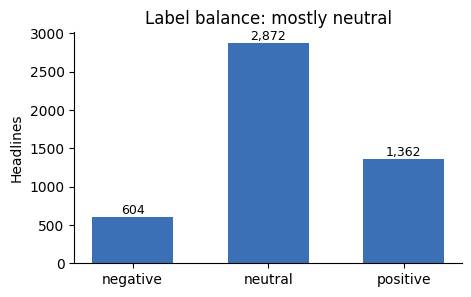

In [10]:
counts = df["sentiment"].value_counts().reindex(LABELS)
print((counts / counts.sum()).round(3))

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(counts.index, counts.values, color="#3b6fb6", width=0.6)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Label balance: mostly neutral")
ax.set_ylabel("Headlines")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

            count  mean   std  min   25%   50%   75%   max
sentiment                                                 
negative    604.0  23.9   9.9  5.0  17.0  22.0  30.0  56.0
neutral    2872.0  22.2   9.8  2.0  15.0  21.0  28.0  81.0
positive   1362.0  24.7  10.1  5.0  17.0  23.0  31.0  57.0


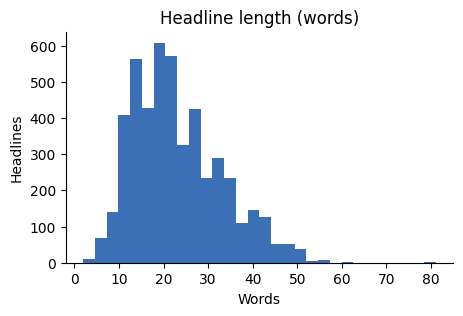

In [11]:
df["words"] = df["headline"].str.split().str.len()
print(df.groupby("sentiment")["words"].describe().round(1))

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(df["words"], bins=30, color="#3b6fb6")
ax.set_title("Headline length (words)")
ax.set_xlabel("Words")
ax.set_ylabel("Headlines")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [12]:
test = held_out_sample(df, n=300)  # fixed seed, stratified
test.to_csv("data/kaggle/test_sample.csv", index=False)
test["sentiment"].value_counts()

,count
sentiment,
neutral,178
positive,85
negative,37


## 4. Classifier evaluation: keyword baseline vs LLM

The LLM classifier is scored on the fixed 300-headline held-out sample with
a sentiment-only prompt. The live news chain uses a longer prompt that also
asks for relevance, but the Kaggle headlines have no target company, so that
instruction would only add noise here. Because LLM output varies between
runs (about 2 points of accuracy at n = 300), the score is the mean of
three runs.

In [13]:
from src.chains.kaggle import keyword_baseline, score, to_articles
from src.chains.news_chain import CLASSIFY_SENTIMENT_SYSTEM, classify

METRICS = ("accuracy", "macro_f1")
N_RUNS = 3  # LLM output varies run to run; report the mean, not one draw

base = score(test["sentiment"], test["headline"].map(keyword_baseline))
print("Keyword baseline:", {k: base[k] for k in METRICS})

articles = to_articles(test)
runs = []
for r in range(N_RUNS):
    labels = classify(articles, system=CLASSIFY_SENTIMENT_SYSTEM)
    pred = [
        labels.get(i, {}).get("sentiment", "neutral")
        for i in range(len(test))
    ]
    runs.append(score(test["sentiment"], pred))
    print(f"LLM run {r + 1}:", {k: runs[-1][k] for k in METRICS})

mean = {k: round(sum(s[k] for s in runs) / N_RUNS, 3) for k in METRICS}
print("LLM mean of", N_RUNS, "runs:", mean)

llm = runs[-1]  # last run's per-class report and confusion matrix
print(llm["report"])

Keyword baseline: {'accuracy': 0.647, 'macro_f1': 0.541}
LLM run 1: {'accuracy': 0.817, 'macro_f1': 0.826}
LLM run 2: {'accuracy': 0.787, 'macro_f1': 0.789}
LLM run 3: {'accuracy': 0.837, 'macro_f1': 0.838}
LLM mean of 3 runs: {'accuracy': 0.814, 'macro_f1': 0.818}
              precision    recall  f1-score   support

    negative       0.76      1.00      0.86        37
     neutral       0.93      0.78      0.85       178
    positive       0.74      0.88      0.80        85

    accuracy                           0.84       300
   macro avg       0.81      0.89      0.84       300
weighted avg       0.85      0.84      0.84       300



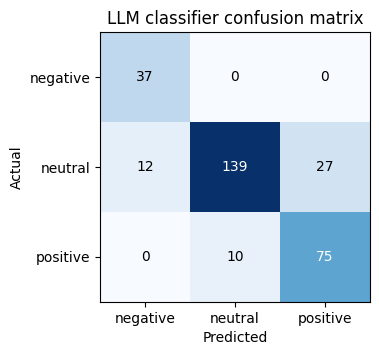

In [14]:
cm = llm["confusion"]

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), LABELS)
ax.set_yticks(range(3), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
for i in range(3):
    for j in range(3):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color)
ax.set_title("LLM classifier confusion matrix")
plt.show()

## 5. News prompt chain: every step printed

**Iteration:** the first run ingested 99 articles, and the digest cited
market roundups that only mentioned Nvidia in passing. Two changes fixed
this: the NewsAPI query now requires the company name in the headline
(`qInTitle`), and the classify step labels each item's relevance so
roundups are dropped before extraction. The trace below shows the new
`RELEVANCE_FILTER` step between `CLASSIFY` and `EXTRACT`.

In [15]:
from src.chains.news_chain import ingest, preprocess, run_news_chain

trace = []
digest = run_news_chain("NVDA", "Nvidia", trace=trace)
for step in trace:
    print(f"\n=== {step['step'].upper()} ===")
    out = step["output"]
    is_item_map = isinstance(out, dict) and all(
        isinstance(k, int) for k in out
    )
    if is_item_map and len(out) > 5:
        out = dict(list(out.items())[:5])  # show first 5 items
    print(out)


=== INGEST ===
{'n': 100, 'sample': ['Prediction: Micron Will Have a Larger Market Cap Than Nvidia by 2030', 'Microsoft releases new Nvidia-chip AI PCs with revamped Windows 11', 'Windows, Surface and Nvidia Event Highlights: Everything Announced in 16 Minutes', 'Windows, Surface and Nvidia Event Highlights: Everything Announced in 16 Minutes', 'Microsoft releases new Nvidia-chip AI PCs with revamped Windows 11 | TechCrunch']}

=== PREPROCESS ===
{'n_in': 100, 'n_out': 93}

=== CLASSIFY ===
{0: {'id': 0, 'topic': 'other', 'sentiment': 'negative', 'relevance': 'high'}, 1: {'id': 1, 'topic': 'product', 'sentiment': 'positive', 'relevance': 'high'}, 2: {'id': 2, 'topic': 'product', 'sentiment': 'neutral', 'relevance': 'high'}, 4: {'id': 4, 'topic': 'product', 'sentiment': 'positive', 'relevance': 'high'}, 5: {'id': 5, 'topic': 'management', 'sentiment': 'negative', 'relevance': 'high'}}

=== RELEVANCE_FILTER ===
{'n_in': 93, 'n_out': 85}

=== EXTRACT ===
{0: {'id': 0, 'entities': ['Micro

In [16]:
# What the relevance filter removed (cached calls, so no extra API cost).
steps = {s["step"]: s["output"] for s in trace}
chain_labels = steps["classify"]
clean = preprocess(ingest("NVDA", "Nvidia"), "Nvidia", "NVDA")

dropped = [
    a.title for a in clean
    if chain_labels.get(a.id, {}).get("relevance") == "low"
]
print(f"Dropped {len(dropped)} low-relevance articles. Examples:")
for title in dropped[:5]:
    print(" -", title)

Dropped 8 low-relevance articles. Examples:
 - New data strengthens our faith in a TJX comeback. Plus, the Nvidia-Microsoft PC is here
 - Top Midday Stories: SpaceX Said to Seek $40 Billion in Financing for Nvidia Chips; Webull Poses National Security Threat, House Panel Reportedly Says
 - NVIDIA And 2 Elite Undervalued Stocks To Own
 - SpaceX Seeks $40B For Nvidia Chips; Iran Steps Up Hormuz Attacks
 - Nvidia vs Tesla vs SK Hynix: Which AI Stock Wins 2026 as Nvidia Nears $6 Trillion and Tesla Earnings Loom


In [17]:
print(digest.model_dump_json(indent=2))

{
  "ticker": "NVDA",
  "net_sentiment": "positive",
  "top_drivers": [
    "Microsoft’s launch of Nvidia-powered AI PCs, including the Surface Laptop Ultra, could broaden Nvidia’s reach in on-device AI computing and Windows PCs. [1][13][15]",
    "SpaceX is reportedly seeking about $40 billion in financing to purchase Nvidia chips, signaling potential large-scale demand for AI compute hardware; the financing and purchase remain reported plans. [23][63][91]",
    "Nvidia’s shares have climbed sharply toward a $6 trillion valuation, reflecting strong investor optimism about AI demand. [70][81][87]",
    "Nvidia-backed AI model initiatives and new software capabilities add to the ecosystem’s product momentum. [69][83][85]"
  ],
  "risks": [
    "A Nvidia director’s reported stock sales—about $946.6 million in the cited account—could weigh on sentiment, though insider selling alone does not establish a change in company fundamentals. [5][38]",
    "Huawei and DeepSeek are developing open-